# 5. Selección de hiperparámetros y posible fuga de datos en Yildiz et al. (2025)

Esta sección resume cómo se interpreta el procedimiento de **selección de hiperparámetros** y **evaluación del pronóstico** usado por Yildiz et al. (2025), con énfasis en una posible **fuga de información** asociada al uso de datos de validación/test durante la selección del modelo.

El objetivo del análisis de pronóstico es aprender una relación temporal de la forma:

$$
(X_{t-1}, X_t) \rightarrow X_{t+1}
$$

Es decir, se usan **dos años consecutivos de batimetría** para predecir el año siguiente.


## 5.1 Selección de hiperparámetros

En la sección de entrenamiento y optimización, los autores indican que usaron **Optuna** para identificar los hiperparámetros óptimos. Sin embargo, el procedimiento descrito no corresponde a una validación cruzada interna de varios pliegues, sino a una partición tipo **hold-out**:

> *"When selecting the parameters, we designated the first 25 years as the training dataset and 20% of this as the validation dataset."*  
> Yildiz et al. (2025), sección 2.3.

Por tanto, la lectura más estricta es:

```text
Primeros 25 años  →  usados para búsqueda de hiperparámetros con Optuna
20% de esos años  →  usado como validación durante la búsqueda
```

No se menciona que la función objetivo de Optuna haya usado **k-fold cross-validation**, ni se reportan métricas promedio entre pliegues. Por eso, en este trabajo la optimización de hiperparámetros parece estar basada en **un único split entrenamiento/validación**.


## 5.2 Hiperparámetros finales reportados para forecasting

Después de la selección con Optuna, los autores reportan una única combinación de hiperparámetros para el modelo ConvLSTM de pronóstico:

| Hiperparámetro | Valor reportado |
|---|---:|
| Convolution filters | 96, 48, 96, 1 |
| Kernel size | (3, 3) |
| Activation function Conv2D | ReLU |
| Learning rate | 0.000279 |
| $\beta_1$, $\beta_2$ Adam | 0.8927, 0.9171 |
| Batch size | 16 |
| Activation function ConvLSTM | ReLU |
| Recurrent activation ConvLSTM | sigmoid |
| ConvLSTM filter | 48 |
| Time step | 2 |

Esto sugiere que los **28 modelos temporales** no tienen hiperparámetros distintos, sino que se entrenan con la misma configuración ya seleccionada.


## 5.3. 28 Modelos one-leave out 

Los autores construyen **28 modelos** desplazando una ventana temporal de tres años. En cada caso:

- los años en **azul** son usados para entrenamiento,
- los años en **naranja** son excluidos del entrenamiento,
- los dos primeros años del bloque naranja funcionan como entrada,
- el tercer año del bloque naranja es el año pronosticado.

Por ejemplo:

```text
Modelo 1:  excluye años 1, 2, 3   → usa 1 y 2 para predecir 3
Modelo 14: excluye años 14,15,16  → usa 14 y 15 para predecir 16
Modelo 28: excluye años 28,29,30  → usa 28 y 29 para predecir 30
```

Este procedimiento sirve para evaluar la **robustez temporal** del enfoque, porque permite observar cómo cambia el error cuando se predicen distintos años de la serie histórica.


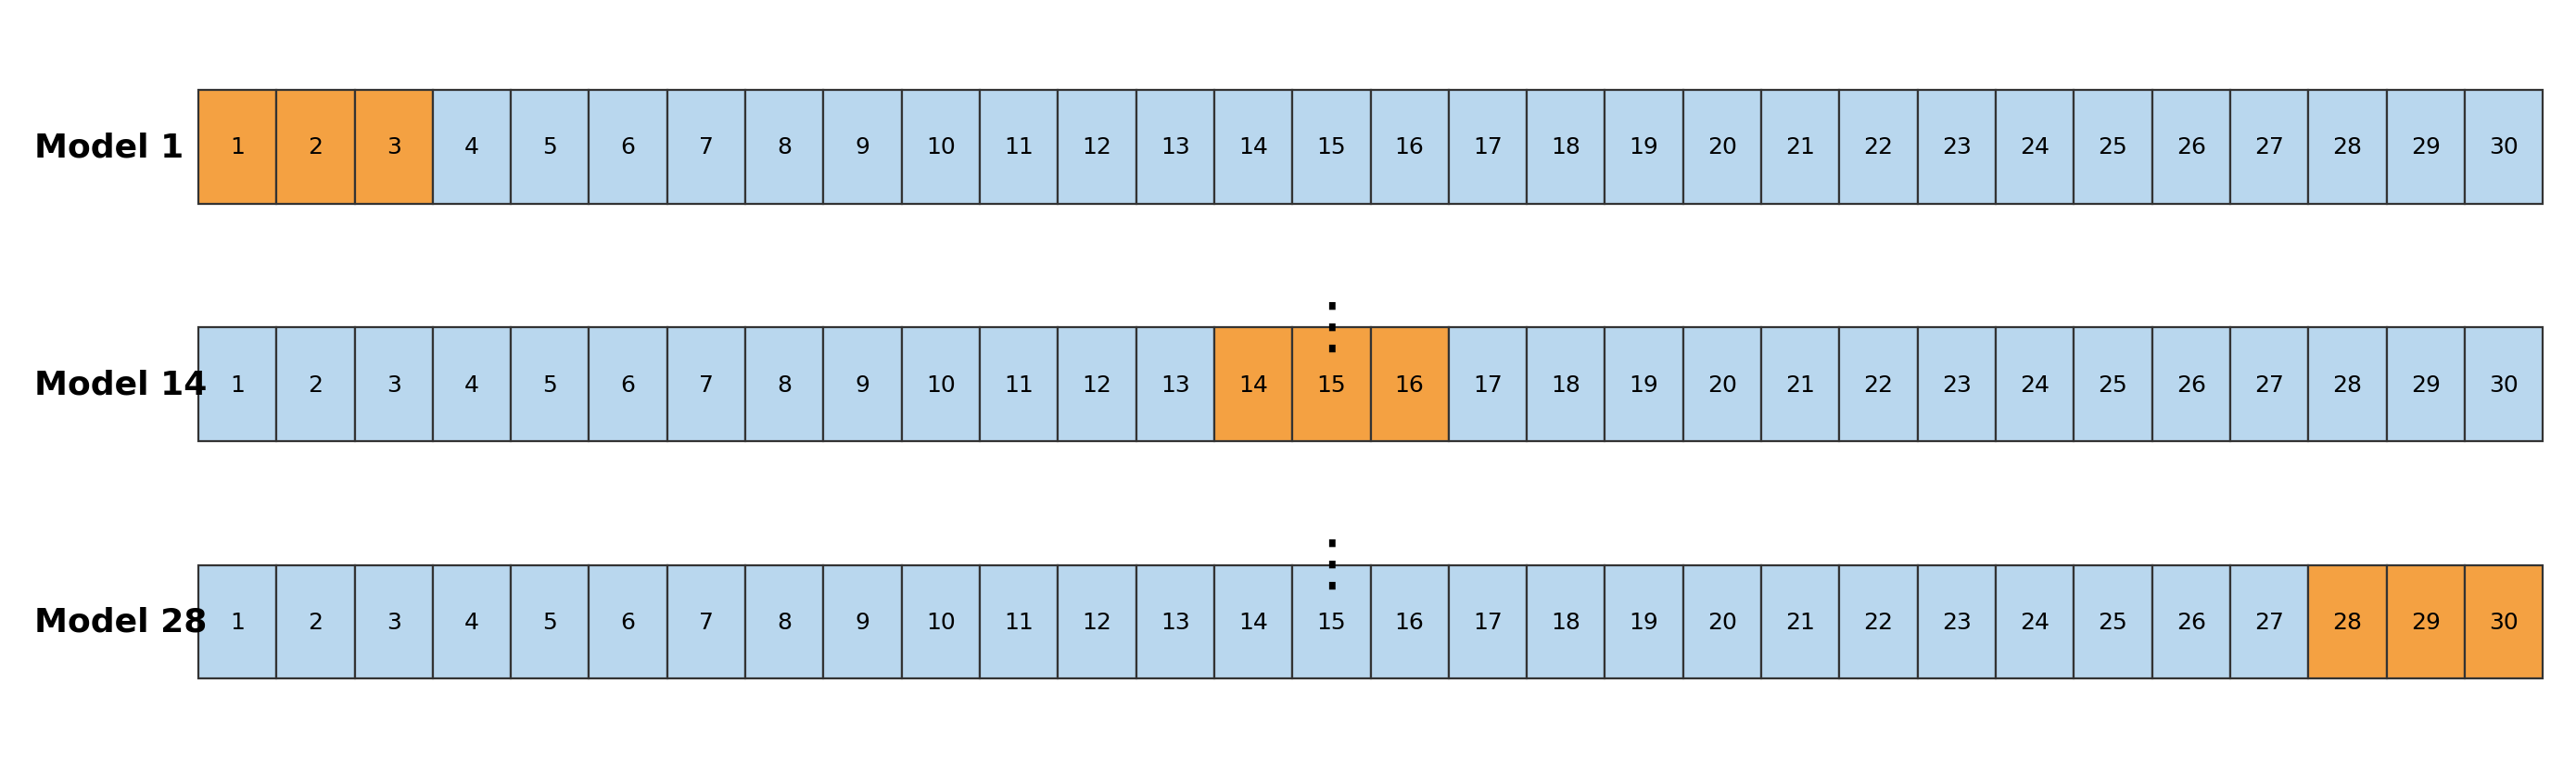

In [1]:

# Figura esquemática del procedimiento de Yildiz et al. (2025)
# Esta celda puede ocultarse en Jupyter Book agregando el tag: hide-input

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

n_years = 30
models_to_show = [1, 14, 28]

fig, ax = plt.subplots(figsize=(14, 4.2))

blue = "#b9d7ee"
orange = "#f4a142"
edge = "#333333"

cell_w = 1.0
cell_h = 0.55
x0 = 2.1
ys = [2.6, 1.45, 0.3]

for row, model in enumerate(models_to_show):
    y = ys[row]
    ax.text(0, y + cell_h/2, f"Model {model}", va="center", ha="left",
            fontsize=13, fontweight="bold")
    test_block = {model, model + 1, model + 2}
    for i in range(1, n_years + 1):
        color = orange if i in test_block else blue
        rect = Rectangle((x0 + (i-1)*cell_w, y), cell_w, cell_h,
                         facecolor=color, edgecolor=edge, linewidth=0.8)
        ax.add_patch(rect)
        ax.text(x0 + (i-1)*cell_w + cell_w/2, y + cell_h/2, str(i),
                va="center", ha="center", fontsize=9, color="black")

# Elipsis entre filas
ax.text(x0 + 14.5*cell_w, 2.0, "⋮", ha="center", va="center", fontsize=24)
ax.text(x0 + 14.5*cell_w, 0.85, "⋮", ha="center", va="center", fontsize=24)

ax.set_xlim(-0.2, x0 + n_years*cell_w + 0.2)
ax.set_ylim(0, 3.5)
ax.axis("off")
plt.tight_layout()
plt.show()


## 5.4. Posible fuga de datos

- La posible fuga no está necesariamente en el entrenamiento de los **pesos** de cada uno de los 28 modelos, porque para cada experimento el bloque naranja se deja por fuera del entrenamiento.

```text
Optuna usó los primeros 25 años para seleccionar hiperparámetros.
Luego, varios de los 28 modelos usan como test años que ya habían participado en esa selección.
```

Esto significa que algunos años evaluados como test pudieron influir indirectamente en la elección del modelo, aunque no se usaran directamente para actualizar los pesos durante el entrenamiento final de cada modelo.

:::{warning}
Esto se considera una posible **fuga de datos a nivel de selección de modelo**.  
No es lo mismo que entrenar los pesos con el test, pero sí puede hacer que la evaluación parezca más optimista.
:::

Sin embargo, usar distintos pliegues significaría entrenar, para cada combinación de hiperparámetros, un modelo por pliegue!


## 5.5 ¿Cuáles modelos estarían estrictamente libres de fuga?

Si se considera como **test** el bloque completo de tres años:

$$
(X_{t-1}, X_t, X_{t+1})
$$

entonces solo los modelos cuyo bloque completo está fuera de los primeros 25 años estarían estrictamente libres de fuga asociada a la selección de hiperparámetros.

Con 30 años numerados del 1 al 30:

```text
Modelo 26: bloque test = 26, 27, 28
Modelo 27: bloque test = 27, 28, 29
Modelo 28: bloque test = 28, 29, 30
```

Por tanto, desde una interpretación estricta, los **modelos 26, 27 y 28** son los únicos cuyo bloque completo de prueba no habría participado en la selección de hiperparámetros.



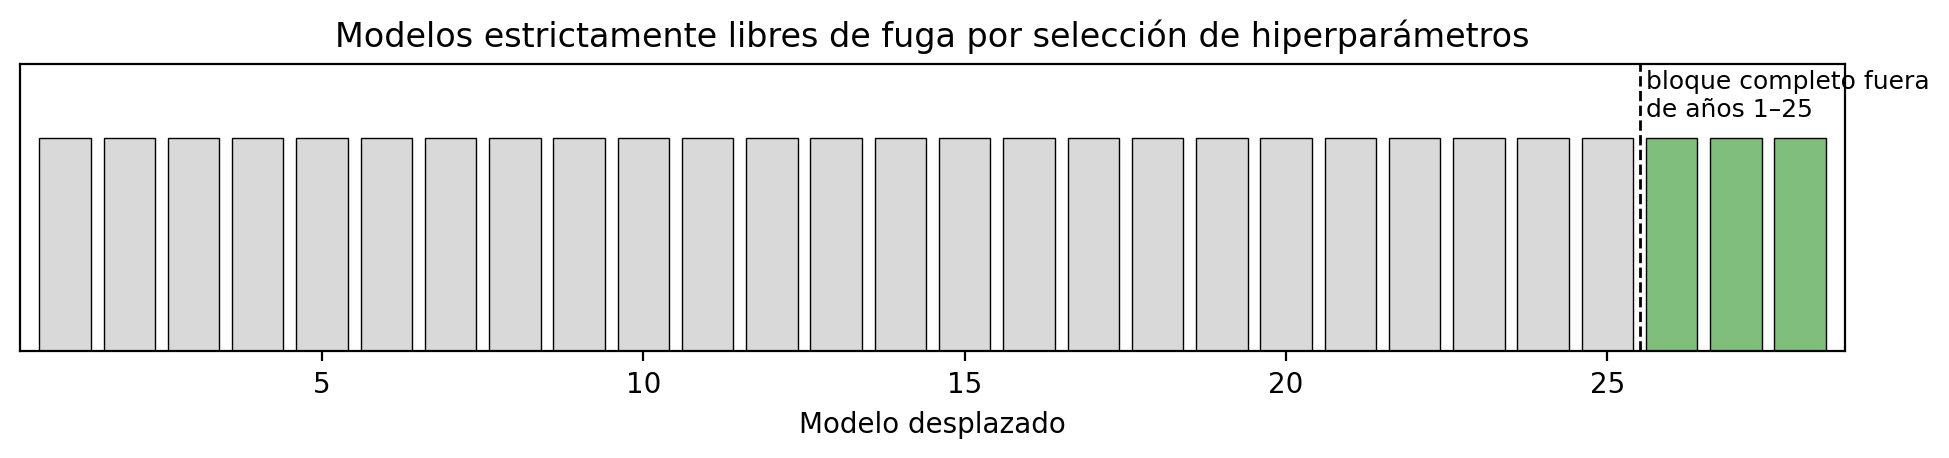

In [3]:

# Visualización simple de qué modelos tienen bloque test completo fuera de Optuna

fig, ax = plt.subplots(figsize=(10, 2.4))

colors = ["#d9d9d9" if not clean else "#7fbf7b" for clean in df["bloque_test_completo_fuera_de_Optuna"]]
ax.bar(df["modelo"], [1]*len(df), color=colors, edgecolor="black", linewidth=0.5)

ax.axvline(25.5, color="black", linestyle="--", linewidth=1)
ax.text(25.6, 1.08, "bloque completo fuera\nde años 1–25", fontsize=9, va="bottom")

ax.set_yticks([])
ax.set_xlabel("Modelo desplazado")
ax.set_title("Modelos estrictamente libres de fuga por selección de hiperparámetros")
ax.set_xlim(0.3, 28.7)
ax.set_ylim(0, 1.35)
plt.tight_layout()
plt.show()


## 5.6. 1755 modelos

:::{figure} ./images/1755Modelos.png
:alt: Modelos con distintas combinaciones de hiperparámetros aplicando validación One-leave out
:width: 90%
:align: center

Figura 1. Validación cruzada One-leave out
:::